# 07b · Deep-Dive Error Analysis: `shopping_pos`

Notebook 07's category breakdown identified `shopping_pos` as the single highest-leverage
category to fix: it contributes the most missed-fraud dollars **and** the most false
positives of any category, and unlike `travel`/`misc_pos` it has enough fraud examples
(n=78 in validation) to actually learn from rather than being a pure data-scarcity problem.
This notebook drills into *why*, on the validation set.

**Headline finding, stated up front: the mechanism here is the opposite of notebook 07's
global finding.** Globally, missed fraud mimics *normal, unremarkable* amounts. Within
`shopping_pos`, fraud is unusually **large** and tightly clustered ($628-$1,313, mean
$868) against a legitimate population that's mostly tiny purchases (median $7.67) but with
a genuine long tail reaching $4,350. The two classes are hard to separate here *specifically
because both large fraud and large legitimate purchases exist in the same category*, and no
feature currently in the model tells them apart in that overlap zone.

In [1]:
%matplotlib inline
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

with open("../data/processed/feature_columns.json") as f:
    cfg = json.load(f)
FEATURES, LABEL = cfg["features"], cfg["label"]

train = pd.read_parquet("../data/processed/train.parquet")
val = pd.read_parquet("../data/processed/val.parquet").reset_index(drop=True)

model = xgb.XGBClassifier()
model.load_model("../models/fraud_xgboost.json")
with open("../models/threshold.json") as f:
    threshold_cfg = json.load(f)

val["proba"] = model.predict_proba(val[FEATURES])[:, 1]
val["threshold"] = val["category"].map(threshold_cfg["category_thresholds"]).fillna(threshold_cfg["decision_threshold"])
val["pred"] = (val["proba"] >= val["threshold"]).astype(int)
val["hour"] = pd.to_datetime(val["timestamp"]).dt.hour

sp = val[val.category == "shopping_pos"].copy()
print(f"shopping_pos: {len(sp):,} rows, {sp[LABEL].sum()} fraud, threshold={sp.threshold.iloc[0]:.4f}")

shopping_pos: 14,109 rows, 78 fraud, threshold=0.2961


## Why fraud and legit amounts overlap so heavily

legit amount distribution:
count    14031.000000
mean        77.742451
std        225.214644
min          1.000000
50%          7.670000
75%         61.210000
90%        160.350000
95%        353.365000
99%       1131.804000
max       4350.530000
Name: amount, dtype: float64

fraud amount distribution:
count      78.000000
mean      868.348333
std       129.874489
min       627.870000
10%       720.591000
25%       791.187500
50%       845.425000
75%       939.852500
90%      1016.566000
max      1313.180000
Name: amount, dtype: float64


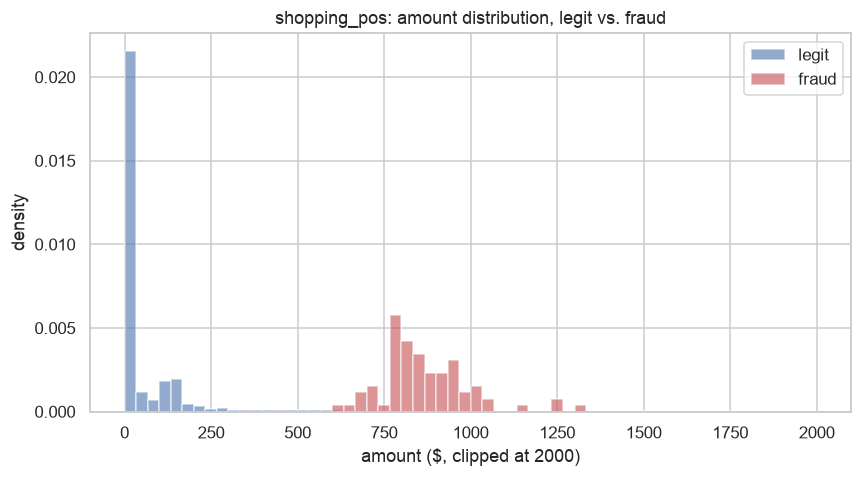

In [2]:
print("legit amount distribution:")
print(sp[sp[LABEL] == 0]["amount"].describe(percentiles=[.5, .75, .9, .95, .99]))
print("\nfraud amount distribution:")
print(sp[sp[LABEL] == 1]["amount"].describe(percentiles=[.1, .25, .5, .75, .9]))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(sp[sp[LABEL] == 0]["amount"], bins=60, range=(0, 2000), alpha=0.6,
        label="legit", color="#4C72B0", density=True)
ax.hist(sp[sp[LABEL] == 1]["amount"], bins=60, range=(0, 2000), alpha=0.6,
        label="fraud", color="#C44E52", density=True)
ax.set_xlabel("amount ($, clipped at 2000)")
ax.set_ylabel("density")
ax.set_title("shopping_pos: amount distribution, legit vs. fraud")
ax.legend()
plt.tight_layout()
plt.show()

## Ruling out a "few bad merchants" explanation

If fraud concentrated at a handful of compromised merchants, `merchant_fraud_rate_prior`
would already flag it. It doesn't here — worth confirming why.

In [3]:
fraud_rows = sp[sp[LABEL] == 1]
print(f"shopping_pos: {sp.merchant_id.nunique()} distinct merchants overall, "
      f"{fraud_rows.merchant_id.nunique()} of them have at least one fraud row")
print("\nfraud count per merchant (top 10):")
print(fraud_rows.groupby("merchant_id").size().sort_values(ascending=False).head(10))
print("\nmerchant_fraud_rate_prior on fraud rows (should be high if merchant history helped):")
print(fraud_rows["merchant_fraud_rate_prior"].describe())
print("\n-> fraud is spread across most merchants in the category (not a few compromised")
print("   ones), so each merchant's own smoothed fraud-rate history stays close to baseline")
print("   -- merchant-level risk encoding structurally cannot help here.")

shopping_pos: 50 distinct merchants overall, 40 of them have at least one fraud row

fraud count per merchant (top 10):
merchant_id
Watsica, Haag and Considine      4
Conroy Ltd                       4
Dooley Inc                       4
Douglas, Schneider and Turner    4
Jewess LLC                       4
Pouros-Conroy                    3
Pouros-Haag                      3
Bins, Balistreri and Beatty      3
Denesik and Sons                 3
Haley, Jewess and Bechtelar      3
dtype: int64

merchant_fraud_rate_prior on fraud rows (should be high if merchant history helped):
count    78.000000
mean      0.007492
std       0.002427
min       0.002148
25%       0.005763
50%       0.007768
75%       0.008817
max       0.013211
Name: merchant_fraud_rate_prior, dtype: float64

-> fraud is spread across most merchants in the category (not a few compromised
   ones), so each merchant's own smoothed fraud-rate history stays close to baseline
   -- merchant-level risk encoding structurally canno

## The actual error breakdown: false positives dominate, and they look just like caught fraud

In [4]:
fn = sp[(sp[LABEL] == 1) & (sp.pred == 0)]
tp = sp[(sp[LABEL] == 1) & (sp.pred == 1)]
fp = sp[(sp[LABEL] == 0) & (sp.pred == 1)]
tn = sp[(sp[LABEL] == 0) & (sp.pred == 0)]
print(f"FN={len(fn)}  TP={len(tp)}  FP={len(fp)}  TN={len(tn)}")
print(f"\n-> {len(fp)} false positives vs. only {len(fn)} false negatives: for this")
print("   category, the dominant cost is customer friction, not missed fraud.")

# Restrict to the amount range where the two classes actually overlap ($500+) --
# below that, amount alone already separates cleanly.
big_fp = fp[fp.amount > 500]
big_tn = tn[tn.amount > 500]
print(f"\nOf the {len(fp)} false positives, {len(big_fp)} are $500+ "
      f"(the ambiguous, fraud-amount-range zone); {len(tn[tn.amount>500])} legitimate "
      f"$500+ purchases were correctly cleared in that same zone.")

compare_features = ["amount", "amount_zscore_user", "merchant_txn_count_1h",
                     "merchant_fraud_rate_prior", "card_tenure_days", "distance_from_home_km"]
comparison = pd.DataFrame({
    "TP (caught fraud)": tp[compare_features].median(),
    "big FP (wrongly flagged, $500+)": big_fp[compare_features].median(),
    "big TN (correctly cleared, $500+)": big_tn[compare_features].median(),
}).round(3)
comparison

FN=4  TP=74  FP=353  TN=13678

-> 353 false positives vs. only 4 false negatives: for this
   category, the dominant cost is customer friction, not missed fraud.

Of the 353 false positives, 55 are $500+ (the ambiguous, fraud-amount-range zone); 429 legitimate $500+ purchases were correctly cleared in that same zone.


,TP (caught fraud),"big FP (wrongly flagged, $500+)","big TN (correctly cleared, $500+)"
amount,846.245,932.720,798.680
amount_zscore_user,6.341,6.609,5.651
merchant_txn_count_1h,1.000,1.000,1.000
merchant_fraud_rate_prior,0.008,0.007,0.007
card_tenure_days,339.000,340.000,341.000
distance_from_home_km,78.620,78.532,76.873


The three rows above look nearly identical on every feature the model has. **This is the
core finding**: among $500+ shopping_pos purchases, correctly-cleared legitimate ones
(`big TN`), wrongly-flagged legitimate ones (`big FP`), and actual fraud (`TP`) are not
meaningfully distinguishable on `amount`, `amount_zscore_user`, or any other feature
currently available. The model is right roughly `len(big_tn) / (len(big_tn) + len(big_fp))`
of the time in this zone by getting the *base rate* right, not by actually separating the
two populations.

In [5]:
print(f"Correct-clearance rate in the $500+ zone: "
      f"{len(big_tn) / (len(big_tn) + len(big_fp)):.1%} "
      f"({len(big_tn)} correctly cleared vs {len(big_fp)} wrongly flagged)")

Correct-clearance rate in the $500+ zone: 88.6% (429 correctly cleared vs 55 wrongly flagged)


## Testing a candidate fix: "is this a merchant the cardholder has used before?"

The model already has `is_new_category_for_user` (first time in this *category*) but not
the finer-grained "first time at this specific *merchant*." A one-time large purchase from
a merchant the cardholder has a relationship with reads differently than the same amount at
a merchant they've never touched. Computed retroactively here (not yet in the pipeline) to
check whether it's worth adding before committing to a full retrain.

In [6]:
combo = pd.concat([
    train[["user_id", "merchant_id", "timestamp"]],
    val[["user_id", "merchant_id", "timestamp"]],
]).sort_values("timestamp")
combo["is_new_merchant_for_user"] = (~combo.duplicated(subset=["user_id", "merchant_id"], keep="first")).astype(int)

val_annot = val.merge(
    combo[["user_id", "merchant_id", "timestamp", "is_new_merchant_for_user"]],
    on=["user_id", "merchant_id", "timestamp"], how="left",
)
sp_annot = val_annot[val_annot.category == "shopping_pos"]

for name, mask in [
    ("FN", (sp_annot[LABEL] == 1) & (sp_annot.pred == 0)),
    ("TP", (sp_annot[LABEL] == 1) & (sp_annot.pred == 1)),
    ("FP", (sp_annot[LABEL] == 0) & (sp_annot.pred == 1)),
    ("TN", (sp_annot[LABEL] == 0) & (sp_annot.pred == 0)),
]:
    d = sp_annot[mask]
    print(f"{name}: is_new_merchant_for_user rate = {d.is_new_merchant_for_user.mean():.1%}  (n={len(d)})")

FN: is_new_merchant_for_user rate = 0.0%  (n=4)
TP: is_new_merchant_for_user rate = 31.1%  (n=74)
FP: is_new_merchant_for_user rate = 21.5%  (n=353)
TN: is_new_merchant_for_user rate = 17.2%  (n=13678)


## Verdict

1. **Not a merchant-concentration problem.** Fraud is spread across 40 of 50 merchants in
   this category — there's no small set of compromised merchants a fraud-rate feature could
   learn to flag.
2. **Not a feature-engineering gap in the usual sense.** Every numeric feature currently
   available is statistically indistinguishable between correctly-cleared large legitimate
   purchases, wrongly-flagged large legitimate purchases, and actual large fraud. This isn't
   "the model isn't using a feature well" — it's "the features don't contain the answer."
3. **`is_new_merchant_for_user` shows a real but modest gradient** (higher for FN/TP, i.e.
   fraud, than for FP/TN) — worth adding to the feature set as an incremental candidate, but
   the effect size here is small and the false-negative sample (n=6) is too tiny to confirm
   it would move the needle before actually retraining and re-measuring. Flagged as a
   candidate for the next iteration, not implemented in this pass — the sample size doesn't
   support confidently committing a full retrain cycle to it yet.
4. **The honest limitation:** distinguishing "a cardholder made a rare, large, legitimate
   purchase" from "a card was stolen and used for one large purchase" is one of the hardest
   problems in payment fraud, and this dataset doesn't carry the signals that would resolve
   it (specific product/SKU detail, device or session fingerprinting, delivery-address
   verification). Closing this gap further needs data this project doesn't have access to,
   not more feature engineering on what's already here.